# 13 — The complete national model: Great Britain, all out

The most complete national transport model of Great Britain this course can
build from open data. **Model size: 194,874 links (~94,000 km) over four road
classes (motorway, trunk, primary and secondary), ~129,000 trigger-built
nodes, and a complete zone system of 350 local-authority districts covering
67.4M residents — carrying 1.35 million peak-hour trips.** On top of it, the
full run of things a transport model can compute and put on a map — zone
choropleths, accessibility, desire lines, equilibrium flows, congestion,
select-link analysis, corridor rankings and national screenlines.

The notebook follows the classic **four-stage model** structure: supply
(network and zones) and travel costs first, then **stage 1, trip
generation**, **stage 2, trip distribution** (stage 3, mode choice, is
deliberately absent — see the note in the demand section), and **stage 4,
assignment** — with the analysis and scenario tooling after.

Every model assumption lives in the **PARAMS** cell below — change a number,
re-run, and the whole model follows.

| file | contents | source |
|---|---|---|
| `uk_roads_dense.geojson.gz` | GB motorways + trunk + primary + secondary roads, topologically noded | © OpenStreetMap contributors (ODbL), Overpass API |
| `gb_lad_zones.geojson.gz` | 350 local-authority districts with boundaries and population | ONS Open Geography (OGL) + NOMIS mid-year estimates (OGL) |
| `gb_boundary.geojson` | GB outline for the maps | public-domain world boundaries |

Nothing is downloaded at run time. The full model builds and runs in roughly
five to ten minutes.


## PARAMS — every model assumption in one place

In [1]:
# Colours and cartographic standards live in uktools/style.py (STYLE dict) -
# model assumptions live here. Rendering never recomputes: every map cell
# below reads precomputed frames, so restyle-and-rerun is instant.
PARAMS = {
    # free-flow speed (km/h) and capacity (veh/h/direction) per link class
    "network": {
        "motorway":  {"speed": 105, "capacity": 4000},
        "trunk":     {"speed": 75,  "capacity": 1800},
        "primary":   {"speed": 60,  "capacity": 1200},
        "secondary": {"speed": 48,  "capacity": 900},
        "ramp":      {"speed": 55,  "capacity": 1500},
    },
    # how each zone is tied into the network
    "connectors": {
        "base": 2, "per_100k_residents": 0.8, "max": 6,
        "min_separation_deg": 0.02, "speed": 40, "capacity": 10000,
    },
    # gravity demand
    "demand": {
        "trip_rate": 0.02,          # inter-district car trips per resident in the peak hour
        "deterrence_beta": 0.05,    # 1/min - steeper than a strategic model: commuting dominates
        "attraction_power": 0.9,    # sublinear population proxy for attractions
    },
    # equilibrium assignment
    "assignment": {
        "algorithm": "bfw", "max_iter": 30, "rgap": 1e-3,
        "vdf_alpha": 0.15, "vdf_beta": 4.0,
    },
    # analysis & display
    "analysis": {
        "select_link_near": (52.48, -1.89),   # M6 at Birmingham
        "desire_lines_top_n": 300,
        "focus": "Birmingham",      # city window for the analyst maps
        "focus_km": 40,
        "flow_display_min": 150,              # veh/h below which links are not drawn
        "screenlines": {
            "England-Scotland border": [(-3.6, 54.98), (-1.8, 55.82)],
            "England-Wales border":    [(-3.15, 53.35), (-2.62, 51.58)],
        },
    },
}


Long computations below (skims, assignments) run inside `progress_box(...)`
— a fixed-height, scrollable panel that stays pinned to the latest progress
bars instead of flooding the notebook. Scroll up inside it for history.
(`AEQ_SHOW_PROGRESS=FALSE` silences AequilibraE's bars entirely.)

In [2]:
import gzip
import json
import time
import warnings
from pathlib import Path
from tempfile import gettempdir
from uuid import uuid4

import geopandas as gpd
import numpy as np
import pandas as pd
from shapely.geometry import LineString, shape

warnings.filterwarnings("ignore")

DATA = Path("data")
with gzip.open(DATA / "uk_roads_dense.geojson.gz", "rt", encoding="utf-8") as fh:
    roads_gj = json.load(fh)
with gzip.open(DATA / "gb_lad_zones.geojson.gz", "rt", encoding="utf-8") as fh:
    zones_gj = json.load(fh)
boundary = gpd.GeoDataFrame(geometry=[shape(f["geometry"]) for f in json.load(open(DATA / "gb_boundary.geojson"))["features"]], crs=4326)

roads = gpd.GeoDataFrame(
    [{"cls": f["properties"]["class"], "ref": f["properties"]["ref"]} for f in roads_gj["features"]],
    geometry=[shape(f["geometry"]) for f in roads_gj["features"]], crs=4326)
zones = gpd.GeoDataFrame(
    [f["properties"] for f in zones_gj["features"]],
    geometry=[shape(f["geometry"]) for f in zones_gj["features"]], crs=4326)
zones["centroid"] = zones.geometry.representative_point()
zones["area_km2"] = zones.to_crs(27700).area / 1e6
zones["density"] = (zones.population / zones.area_km2).round(0)

km_by_cls = (roads.assign(km=roads.to_crs(27700).length / 1000).groupby("cls").km.sum().round(0))
print(f"network: {len(roads):,} links / {km_by_cls.sum():,.0f} km   "
      f"zones: {len(zones)} districts / {zones.population.sum() / 1e6:.1f}M residents")
km_by_cls.astype(int)

network: 194,874 links / 94,409 km   zones: 350 districts / 67.4M residents


cls
motorway      7078
primary      27557
ramp          3671
secondary    29240
trunk        26863
Name: km, dtype: int64

In [3]:
# Maps, cartographic standards and UK geography helpers.
# Model logic stays in the notebook; everything reusable lives in notebooks/uktools/.
from uktools import *


## The zone system

Every local-authority district in Great Britain, coloured by population
density — the first thing any model report shows.

In [4]:
zones["log_density"] = np.log10(zones.density.clip(lower=1)).round(3)
doc = new_map()
add_gdf(doc, zones[["name", "population", "density", "log_density", "geometry"]],
        "population density", opacity=0.8,
        symbology=[[field("log_density").colormap(STYLE["density_ramp"], domain=(0.5, 4.0)).encoding("fill")]],
        tooltip=["name", "population", "density"])   # hover a district: name + numbers, highlighted
doc


[interactive offline map - run the notebook to display]

## The network

Four road classes, ~100,000+ links:

In [5]:
doc = new_map()
add_underlay(doc)
for cls_name in ["secondary", "primary", "trunk", "motorway"]:
    add_gdf(doc, merge_lines(roads[roads.cls == cls_name], tol=0.02), cls_name,
            symbology=class_style(cls_name))
doc.show(controls=True)   # tick road classes on and off


[interactive offline map - run the notebook to display]

## Supply — 1. build the model network

Every link through the editing triggers, attributes from PARAMS.


In [6]:
from aequilibrae.project import Project

fldr = str(Path(gettempdir()) / uuid4().hex)
project = Project()
project.new(fldr)

t0 = time.perf_counter()
with project.db_connection as conn:
    for lt, spec in PARAMS["network"].items():
        conn.execute("insert into link_types (link_type, link_type_id, description, speed) values (?,?,?,?)",
                     (lt, lt[0] if lt != "secondary" else "x", f"{lt} (GB)", spec["speed"]))
    lid = 0
    for f in roads_gj["features"]:
        cls = f["properties"]["class"]
        coords = f["geometry"]["coordinates"]
        if coords[0] == coords[-1]:
            continue
        spec = PARAMS["network"][cls]
        lid += 1
        wkt = "LINESTRING(" + ", ".join(f"{x} {y}" for x, y in coords) + ")"
        conn.execute(
            "insert into links (link_id, a_node, b_node, link_type, modes, direction, "
            " speed_ab, speed_ba, capacity_ab, capacity_ba, name, geometry) "
            "values (?, 0, 0, ?, 'c', 0, ?, ?, ?, ?, ?, GeomFromText(?, 4326))",
            (lid, cls, spec["speed"], spec["speed"], spec["capacity"], spec["capacity"],
             f["properties"]["ref"], wkt))
    conn.execute("update links set travel_time_ab = distance / 1000.0 / speed_ab * 60, "
                 "travel_time_ba = distance / 1000.0 / speed_ba * 60")
    conn.commit()
    n_nodes = conn.execute("select count(*) from nodes").fetchone()[0]
print(f"inserted {lid:,} links in {time.perf_counter() - t0:.0f}s; triggers created {n_nodes:,} nodes")

inserted 194,864 links in 100s; triggers created 129,493 nodes


## Supply — 2. connect the zone system

Each district's centroid ties into the network with population-scaled, spread-out connectors.


In [7]:
from scipy.spatial import cKDTree

CP = PARAMS["connectors"]
nodes_df = project.network.nodes.data
xy = np.c_[nodes_df.geometry.x * np.cos(np.radians(54.5)), nodes_df.geometry.y]
tree = cKDTree(xy)

t0 = time.perf_counter()
with project.db_connection as conn:
    for z in zones.itertuples():
        n_conn = int(np.clip(CP["base"] + z.population / 100_000 * CP["per_100k_residents"],
                             CP["base"], CP["max"]))
        cx, cy = z.centroid.x, z.centroid.y
        _, idx = tree.query([cx * np.cos(np.radians(54.5)), cy], k=400)
        chosen = []
        for j in np.atleast_1d(idx):
            pt = nodes_df.geometry.iloc[int(j)]
            if all(abs(pt.x - q.x) + abs(pt.y - q.y) > CP["min_separation_deg"] for q in chosen):
                chosen.append(pt)
            if len(chosen) == n_conn:
                break
        for pt in chosen:
            lid += 1
            conn.execute(
                "insert into links (link_id, a_node, b_node, link_type, modes, direction, "
                " speed_ab, speed_ba, capacity_ab, capacity_ba, name, geometry) "
                "values (?, 0, 0, 'centroid_connector', 'c', 0, ?, ?, ?, ?, ?, GeomFromText(?, 4326))",
                (lid, CP["speed"], CP["speed"], CP["capacity"], CP["capacity"],
                 f"{z.name} connector", f"LINESTRING({cx} {cy}, {pt.x} {pt.y})"))
    conn.execute("update links set travel_time_ab = distance / 1000.0 / speed_ab * 60, "
                 "travel_time_ba = distance / 1000.0 / speed_ba * 60 where travel_time_ab is null")
    conn.commit()

nodes_df = project.network.nodes.data
key = (nodes_df.geometry.x.round(5).astype(str) + "|" + nodes_df.geometry.y.round(5).astype(str))
lookup = dict(zip(key, nodes_df.node_id))
zones["node_id"] = [lookup[f"{round(z.centroid.x, 5)}|{round(z.centroid.y, 5)}"] for z in zones.itertuples()]

with project.db_connection as conn:
    conn.executemany("update nodes set is_centroid = 1 where node_id = ?",
                     [(int(n),) for n in zones.node_id])
    conn.commit()
print(f"{len(zones)} zones connected in {time.perf_counter() - t0:.0f}s")

350 zones connected in 4s


## Travel costs — national skims

Zone-to-zone generalised costs: the input every demand stage feeds on.


In [8]:
from aequilibrae.paths import NetworkSkimming

project.network.build_graphs(modes=["c"])
graph = project.network.graphs["c"]
graph.set_graph("travel_time")
graph.set_skimming(["travel_time", "distance"])
graph.set_blocked_centroid_flows(True)

t0 = time.perf_counter()
skimmer = NetworkSkimming(graph)
with progress_box("National skim"):
    skimmer.execute()
tt = np.array(skimmer.results.skims.get_matrix("travel_time"), copy=True)
dist = np.array(skimmer.results.skims.get_matrix("distance"), copy=True)
print(f"skimmed {tt.shape[0]}x{tt.shape[0]} district pairs in {time.perf_counter() - t0:.1f}s")

by_node = zones.set_index("node_id").reindex(graph.centroids)


[interactive offline map - run the notebook to display]

skimmed 350x350 district pairs in 1.3s


## Accessibility on the map

A skim is a matrix; on a map it becomes accessibility. Free-flow drive time
from Westminster to every district in Great Britain:

In [9]:
origin_idx = int(np.argmax(by_node.name.values == "Westminster"))
zones_t = zones.merge(pd.DataFrame({"node_id": by_node.index, "from_london_h": (tt[origin_idx] / 60).round(2)}),
                      on="node_id")
doc = new_map()
add_gdf(doc, zones_t[["name", "from_london_h", "geometry"]], "drive time from London (h)",
        opacity=0.8,
        symbology=[[field("from_london_h").colormap(STYLE["access_ramp"], reverse=True, domain=(0.0, 10.0)).encoding("fill")]],
        tooltip=["name", "from_london_h"])
doc


[interactive offline map - run the notebook to display]

## Stages 1 & 2 — trip generation and distribution

**Stage 1, trip generation**: productions from residents and a sublinear
population proxy for attractions, balanced to the same total. **Stage 2,
trip distribution**: an exponential-deterrence gravity model on the skim
costs, balanced with doubly-constrained IPF. Both driven from PARAMS.


In [10]:
DP = PARAMS["demand"]
pop = by_node.population.to_numpy(dtype=float)
productions = pop * DP["trip_rate"]
attractions = np.power(pop, DP["attraction_power"])
attractions *= productions.sum() / attractions.sum()

imp = tt.copy()
np.fill_diagonal(imp, np.nan)
imp[~np.isfinite(imp)] = np.nan

T = np.outer(productions, attractions) * np.exp(-DP["deterrence_beta"] * np.nan_to_num(imp, nan=1e4))
T[np.isnan(imp)] = 0.0
np.fill_diagonal(T, 0.0)
for it in range(100):
    rs = T.sum(1); T *= np.divide(productions, rs, out=np.zeros_like(rs), where=rs > 0)[:, None]
    cs = T.sum(0); T *= np.divide(attractions, cs, out=np.zeros_like(cs), where=cs > 0)[None, :]
    if np.abs(T.sum(1) - productions).sum() / productions.sum() < 1e-5:
        break
print(f"{T.sum():,.0f} inter-district trips in the peak hour "
      f"(mean trip {np.average(np.nan_to_num(imp, nan=0), weights=T):,.0f} min, "
      f"{np.average(np.nan_to_num(dist, nan=0), weights=T) / 1000:,.0f} km)")

1,348,913 inter-district trips in the peak hour (mean trip 47 min, 59 km)

> **Stage 3, mode choice, is deliberately absent.** This is a car-only
> strategic model: every trip in the matrix is a car trip. In a full
> four-stage model a mode-choice step (typically a logit split on
> generalised costs) would sit exactly here, between distribution and
> assignment, splitting the person-trip matrix into car, public transport
> and active modes. Notebook 07's GTFS transit database is where a public
> transport network for such a split would come from.

The trip-length distribution — the first sanity check of any demand model:

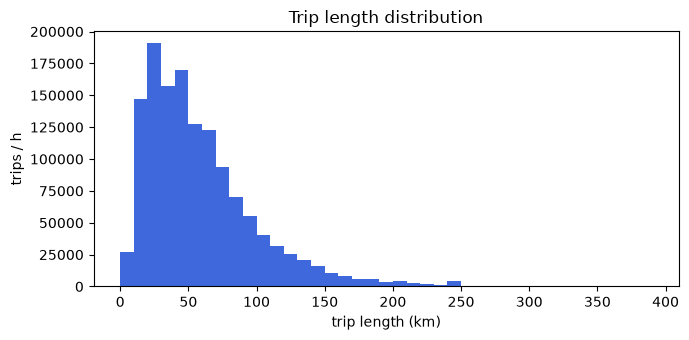

In [11]:
import matplotlib.pyplot as plt

w = T.flatten()
d_km = np.nan_to_num(dist, nan=0).flatten() / 1000
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(d_km, bins=np.arange(0, 400, 10), weights=w, color="#1d4ed8", alpha=0.85)
ax.set_xlabel("trip length (km)"); ax.set_ylabel("trips / h")
ax.set_title("Trip length distribution")
plt.tight_layout()

## Desire lines

Demand before it meets the network: the biggest district-to-district movements
drawn as straight lines, width scaled by trips.

In [12]:
N = PARAMS["analysis"]["desire_lines_top_n"]
flat = [(i, j, T[i, j]) for i in range(len(T)) for j in range(len(T)) if T[i, j] > 0]
top = sorted(flat, key=lambda x: -x[2])[:N]
cent = by_node.centroid.values
desire = gpd.GeoDataFrame(
    {"from": by_node.name.values[[i for i, j, v in top]],
     "to": by_node.name.values[[j for i, j, v in top]],
     "trips": [round(v) for i, j, v in top]},
    geometry=[LineString([cent[i], cent[j]]) for i, j, v in top], crs=4326)

dmax = float(desire.trips.max())
doc = new_map(boundary, zoom=6)
add_underlay(doc)
add_gdf(doc, desire, f"top {N} desire lines", tooltip=["from", "to", "trips"],
        symbology=[[field("trips").colormap(STYLE["desire_ramp"], domain=(0.0, dmax)).encoding("stroke"),
                    field("trips").scalar(domain=(0.0, dmax), output_range=(0.5, 8.0)).encoding("stroke-width")]])
doc


[interactive offline map - run the notebook to display]

## Stage 4 — equilibrium assignment with select link

The full national equilibrium, with a select-link flag on the M6 through
Birmingham so we can afterwards see exactly whose traffic uses it.


In [13]:
from aequilibrae.matrix import AequilibraeMatrix
from aequilibrae.paths import TrafficAssignment, TrafficClass

links_gdf = project.network.links.data
sl_lat, sl_lon = PARAMS["analysis"]["select_link_near"][0], PARAMS["analysis"]["select_link_near"][1]
mways = links_gdf[links_gdf.link_type == "motorway"].copy()
sel_id = int(mways.iloc[(mways.geometry.centroid.distance(gpd.points_from_xy([sl_lon], [sl_lat])[0])).argmin()].link_id)
print(f"select link: motorway link {sel_id} nearest ({sl_lat}, {sl_lon})")

demand = AequilibraeMatrix()
demand.create_empty(zones=graph.num_zones, matrix_names=["matrix"], memory_only=True)
demand.index = graph.centroids[:]
demand.matrices[:, :, 0] = T
demand.computational_view()

AP = PARAMS["assignment"]
car = TrafficClass(name="car", graph=graph, matrix=demand)
car.set_select_links({"m6_birmingham": [(sel_id, 0)]})
assig = TrafficAssignment()
assig.add_class(car)
assig.set_vdf("BPR")
assig.set_vdf_parameters({"alpha": AP["vdf_alpha"], "beta": AP["vdf_beta"]})
assig.set_capacity_field("capacity")
assig.set_time_field("travel_time")
assig.set_algorithm(AP["algorithm"])
assig.max_iter = AP["max_iter"]
assig.rgap_target = AP["rgap"]
t0 = time.perf_counter()
with progress_box("National equilibrium assignment"):
    assig.execute()
assig.save_results("peak")
assig.save_select_link_results("m6_analysis")
print(f"equilibrium in {time.perf_counter() - t0:.0f}s")


select link: motorway link 119526 nearest (52.48, -1.89)


[interactive offline map - run the notebook to display]

equilibrium in 42s


## Two views of the loaded network

Flow — where the traffic is:

In [14]:
# Render-only cell: restyle and re-run freely - nothing recomputes.
res = assig.results()
loaded = links_gdf.merge(res.reset_index(), on="link_id")
loaded = loaded[(loaded.matrix_tot > PARAMS["analysis"]["flow_display_min"])
                & (loaded.link_type != "centroid_connector")].copy()
loaded["flow"] = loaded.matrix_tot.round(0)
loaded["voc"] = loaded["VOC_max"].clip(upper=1.5).round(3)
loaded["geometry"] = loaded.geometry.simplify(0.004)
fmax = float(loaded.flow.max())

doc = new_map()
add_underlay(doc)
add_gdf(doc, loaded[["link_id", "name", "flow", "geometry"]], "traffic flow (veh/h)",
        symbology=flow_style("flow", fmax), tooltip=["name", "flow"])
doc   # tip: doc.show(sidecar="National flows") opens this in a side panel


[interactive offline map - run the notebook to display]

Congestion — where the network struggles:

In [15]:
used = loaded[loaded.flow > 0]
print(f"mean V/C {used.VOC_max.mean():.2f}, max {used.VOC_max.max():.2f}, "
      f"{(used.VOC_max > 1).mean() * 100:.1f}% of drawn links over capacity")

doc = new_map()
add_underlay(doc)
add_gdf(doc, loaded[["link_id", "name", "voc", "flow", "geometry"]], "congestion (V/C)",
        symbology=congestion_style("voc", "flow", fmax), tooltip=["name", "voc", "flow"])
doc


mean V/C 0.48, max 3.31, 7.6% of drawn links over capacity


[interactive offline map - run the notebook to display]

## Analyst toolkit

The national views get cramped - these tools zoom, filter and interrogate.
Every one is render-only: the model frames above are reused, nothing
recomputes.

**Focus windows.** `focus_map("Birmingham", km=40)` (any city; or
`"district:Manchester"`, or an explicit bbox) clips every layer to the window:

In [16]:
FOC = PARAMS["analysis"]
doc = focus_map(FOC["focus"], km=FOC["focus_km"])
add_gdf(doc, loaded[["link_id", "name", "voc", "flow", "geometry"]], "congestion",
        symbology=congestion_style("voc", "flow", fmax), tooltip=["name", "voc", "flow"])
add_gdf(doc, zones[["name", "geometry"]], "districts", opacity=0.2,
        symbology=[[constant(STYLE["boundary_fill"]).encoding("fill")]], tooltip=["name"])
doc

[interactive offline map - run the notebook to display]

**Layer toggles.** `split_by` gives each road class its own layer and
`show(controls=True)` puts checkboxes beside the map - untick to remove a
class from view:

In [17]:
doc = new_map()
add_underlay(doc)
add_gdf(doc, loaded[["link_id", "name", "link_type", "flow", "geometry"]], "flow",
        symbology=flow_style("flow", fmax), tooltip=["name", "flow"],
        split_by="link_type")
doc.show(controls=True)

[interactive offline map - run the notebook to display]

**Box selection.** Hold *Shift* and drag on the map above, then read the
bounds back - feed them straight into `focus_map(...)` or clip any frame with
`gdf.cx[minx:maxx, miny:maxy]`:

In [18]:
print("drag a box on the map above (Shift+drag), then re-run this cell:")
print("selection bounds:", doc.selection())

drag a box on the map above (Shift+drag), then re-run this cell:
selection bounds: None


**Geometric selection and surgical edits.** `near()` picks features by
place and radius, chains with attribute filters, and `edit_links()` writes
speed/capacity changes for the selection straight into the model database
(rebuild graphs afterwards to re-assign):

In [19]:
sel = near(loaded, "Birmingham", miles=5).query("link_type == 'motorway'")
print(f"{len(sel)} motorway links within 5 miles of central Birmingham")
display(sel[["link_id", "name", "flow", "voc"]].head())
# the same pattern with any place/radius/attributes, e.g.
#   near(loaded, "London", miles=3).query("link_type == 'motorway'")
# surgical model edits on a selection (then rebuild graphs and re-run stage 4):
#   edit_links(project, sel, speed=40)              # slow them to 40 km/h
#   edit_links(project, sel, capacity_factor=0.5)   # or throttle capacity
#   close_direction(project, sel, close="ab")       # or close one direction
sel_summary = f"{len(sel)} links selected"
sel_summary

24 motorway links within 5 miles of central Birmingham


,link_id,name,flow,voc
224,225,M6,5277.0,0.698
226,227,A38(M),412.0,0.052
227,228,A38(M),1084.0,0.195
235,236,A38(M),4077.0,0.543
236,237,M6,4287.0,0.569


'24 links selected'

## Select link: who uses the M6 through Birmingham?

Every link carrying traffic that also crosses the flagged M6 section — the
classic question a select-link analysis answers:

In [20]:
with project.results_connection as conn:
    sl = pd.read_sql("select * from m6_analysis", conn)
if "link_id" not in sl.columns:
    sl = sl.rename(columns={sl.columns[0]: "link_id"})
tot_cols = [c for c in sl.columns if c.endswith("_tot")]
sl["sl_flow"] = sl[tot_cols].sum(axis=1)
sl = sl[sl.sl_flow > 25]
slg = links_gdf.merge(sl[["link_id", "sl_flow"]], on="link_id")
slg["geometry"] = slg.geometry.simplify(0.004)
print(f"{len(slg):,} links carry M6-Birmingham traffic")

doc = new_map(boundary, zoom=6)
add_underlay(doc)
add_gdf(doc, slg[["link_id", "sl_flow", "geometry"]], "M6 users", tooltip=["sl_flow"],
        symbology=[[field("sl_flow").colormap(STYLE["select_ramp"], domain=(0.0, float(slg.sl_flow.max()))).encoding("stroke"),
                    field("sl_flow").scalar(domain=(0.0, float(slg.sl_flow.max())), output_range=(0.7, 6.5)).encoding("stroke-width")]])
add_gdf(doc, links_gdf[links_gdf.link_id == sel_id], "the M6 section",
        symbology=[[constant(STYLE["emphasis"]).encoding("stroke"), constant(6.0).encoding("stroke-width")]])
doc


205 links carry M6-Birmingham traffic


[interactive offline map - run the notebook to display]

## The busiest corridors

In [21]:
loaded["veh_km"] = loaded["matrix_tot"] * loaded["distance"] / 1000
corridors = (loaded[loaded["name"].str.len() > 0].groupby("name")
             .agg(veh_km=("veh_km", "sum"), peak_flow=("matrix_tot", "max"))
             .nlargest(12, "veh_km").round(0).astype(int))
corridors

,veh_km,peak_flow
name,,
M1,3633204,10540
M6,3522856,9553
M4,2653364,9573
M5,2373937,8166
M25,2355745,7871
M62,1584392,9763
A1(M),1517239,6236
A38,1095138,8483
M40,1044205,5487


In [22]:
cor = loaded[loaded["name"].isin(corridors.index)]
doc = new_map(boundary, zoom=6)
add_underlay(doc, roads_gdf=loaded)
add_gdf(doc, cor[["link_id", "name", "flow", "geometry"]], "busiest corridors", tooltip=["name", "flow"],
        symbology=[[field("name").categorical("tab20").encoding("stroke"),
                    field("flow").scalar(domain=(0.0, fmax), output_range=(1.2, 6.5)).encoding("stroke-width")]])
doc


[interactive offline map - run the notebook to display]

## National screenlines

In [23]:
rows = []
for sname in PARAMS["analysis"]["screenlines"]:
    hit, tot = crossings(loaded, sname)
    rows.append({"screenline": sname, "links": len(hit), "veh_per_hour": round(tot)})
pd.DataFrame(rows)


,screenline,links,veh_per_hour
0,England-Scotland border,6,7223
1,England-Wales border,20,23536


## Comparing runs: what if the M6 lost half its capacity?

Scenario analysis is where a model earns its keep. The compute cell below
builds the scenario (edit the factor and re-run); the render cells after it
only draw - restyle them as often as you like without recomputing.

In [24]:
# ---- compute: scenario assignment (M6 capacity x0.5) --------------------
SCENARIO_FACTOR = 0.5
with project.db_connection as conn:
    conn.execute("update links set capacity_ab = capacity_ab * ?, capacity_ba = capacity_ba * ? "
                 "where name = 'M6'", (SCENARIO_FACTOR, SCENARIO_FACTOR))
    conn.commit()
project.network.build_graphs(modes=["c"])
graph2 = project.network.graphs["c"]
graph2.set_graph("travel_time")
graph2.set_blocked_centroid_flows(True)

demand2 = AequilibraeMatrix()
demand2.create_empty(zones=graph2.num_zones, matrix_names=["matrix"], memory_only=True)
demand2.index = graph2.centroids[:]
demand2.matrices[:, :, 0] = T
demand2.computational_view()

assig2 = TrafficAssignment()
assig2.add_class(TrafficClass(name="car", graph=graph2, matrix=demand2))
assig2.set_vdf("BPR")
assig2.set_vdf_parameters({"alpha": AP["vdf_alpha"], "beta": AP["vdf_beta"]})
assig2.set_capacity_field("capacity")
assig2.set_time_field("travel_time")
assig2.set_algorithm(AP["algorithm"])
assig2.max_iter = AP["max_iter"]
assig2.rgap_target = AP["rgap"]
with progress_box("Scenario assignment (M6 capacity x0.5)"):
    assig2.execute()

links_scen = project.network.links.data   # network AFTER the capacity edit
res2 = assig2.results()
loaded2 = links_gdf.merge(res2.reset_index(), on="link_id")
loaded2 = loaded2[(loaded2.matrix_tot > PARAMS["analysis"]["flow_display_min"])
                  & (loaded2.link_type != "centroid_connector")].copy()
loaded2["flow"] = loaded2.matrix_tot.round(0)
loaded2["geometry"] = loaded2.geometry.simplify(0.004)

diff = links_gdf.merge(res.reset_index()[["link_id", "matrix_tot"]], on="link_id") \
               .merge(res2.reset_index()[["link_id", "matrix_tot"]], on="link_id",
                      suffixes=("_base", "_scen"))
diff["delta"] = (diff.matrix_tot_scen - diff.matrix_tot_base).round(0)
diff = diff[(diff.delta.abs() > 100) & (diff.link_type != "centroid_connector")].copy()
diff["geometry"] = diff.geometry.simplify(0.004)
print(f"{len(diff):,} links change by more than 100 veh/h; "
      f"largest increase {diff.delta.max():,.0f}, largest decrease {diff.delta.min():,.0f}")


[interactive offline map - run the notebook to display]

11,010 links change by more than 100 veh/h; largest increase 3,477, largest decrease -3,845


**The network difference itself.** Not only flows — any link attribute can
be differenced between two networks or runs with `compare_links`. Here is the
exact change we made: the M6's halved capacity (blue = capacity removed),
in a Midlands window:

In [25]:
# ---- render: capacity change between the two networks --------------------
cap = compare_links(links_gdf, links_scen, "capacity_ab", min_abs=1)
doc = focus_map("Birmingham", km=90)
add_underlay(doc)
add_gdf(doc, cap[["link_id", "capacity_ab_base", "capacity_ab_scen", "delta", "geometry"]],
        "capacity change (veh/h)",
        symbology=diff_style("delta", float(cap.delta.abs().max())),
        tooltip=["capacity_ab_base", "capacity_ab_scen", "delta"])
doc

[interactive offline map - run the notebook to display]

The difference map - red gained traffic, blue lost it (the weakened M6):

In [26]:
# ---- render: scenario difference ----------------------------------------
dmax = float(diff.delta.abs().quantile(0.98))
doc = new_map()
add_underlay(doc)
add_gdf(doc, diff[["link_id", "name", "delta", "geometry"]], "flow change (veh/h)",
        symbology=diff_style("delta", dmax), tooltip=["name", "delta"])
doc

[interactive offline map - run the notebook to display]

And the two runs side by side:

In [27]:
# ---- render: side-by-side comparison ------------------------------------
a = new_map(height=420); add_underlay(a)
add_gdf(a, loaded[["link_id", "name", "flow", "geometry"]], "base",
        symbology=flow_style("flow", fmax), tooltip=["name", "flow"])
b = new_map(height=420); add_underlay(b)
add_gdf(b, loaded2[["link_id", "name", "flow", "geometry"]], "scenario",
        symbology=flow_style("flow", fmax), tooltip=["name", "flow"])
side_by_side(a, b, titles=("Base", f"M6 capacity x{SCENARIO_FACTOR}"))

[interactive offline map - run the notebook to display]

## The model on one page

In [28]:
# ---- render: the model on one page (one unified card) --------------------
vkt = (loaded.assign(vkm=loaded.matrix_tot * loaded["distance"] / 1000)
       .groupby("link_type").vkm.sum() / 1e6)
vkt_df = (vkt.round(2).sort_values(ascending=False).reset_index()
          .rename(columns={"link_type": "road class", "vkm": "million veh-km/h"}))
vkt_df["share"] = (100 * vkt_df["million veh-km/h"] / vkt_df["million veh-km/h"].sum()).round(1)

sl_rows = []
for sname in PARAMS["analysis"]["screenlines"]:
    hit, tot = crossings(loaded, sname)
    sl_rows.append({"screenline": sname, "links": len(hit), "veh/h": f"{tot:,.0f}"})

summary_card(
    "GB national model - one page",
    {
        "Supply": {
            "network": f"{len(roads):,} links / {km_by_cls.sum():,.0f} km",
            "zone system": f"{len(zones)} districts",
            "population": f"{zones.population.sum() / 1e6:.1f}M residents",
        },
        "Demand": {
            "peak-hour trips": f"{T.sum():,.0f}",
            "mean trip length": f"{np.average(np.nan_to_num(dist, nan=0), weights=T) / 1000:.0f} km",
            "mean trip time": f"{np.average(np.nan_to_num(tt, nan=0), weights=T):.0f} min free-flow",
        },
        "Loaded network": {
            "vehicle-km travelled": f"{vkt.sum():.1f}M per hour",
            "mean V/C (drawn links)": f"{used.VOC_max.mean():.2f}",
            "max V/C": f"{used.VOC_max.max():.2f}",
            "links over capacity": f"{(used.VOC_max > 1).mean() * 100:.1f}%",
        },
    },
    tables={"Vehicle-km by road class": vkt_df,
            "National screenlines": pd.DataFrame(sl_rows)},
    footnote="Base run; the scenario comparison section above carries the M6 sensitivity figures.",
)


road class,million veh-km/h,share
trunk,32.7,44.1%
motorway,28.31,38.2%
primary,9.93,13.4%
secondary,1.94,2.6%
ramp,1.25,1.7%
screenline,links,veh/h
England-Scotland border,6,"7,223"
England-Wales border,20,"23,536"


## Wrap-up, provenance and licences

One notebook, the whole toolkit: a complete open-data zone system, a
four-class national network built through the consistency triggers,
skims turned into accessibility maps, gravity demand with its trip-length
distribution and desire lines, a converged select-link equilibrium, flow and
congestion views, corridor rankings, national screenlines and a summary page —
with every assumption in one PARAMS cell, ready to be changed.

**Provenance.** Road network © OpenStreetMap contributors (ODbL), Overpass API
extract (motorway/trunk/primary/secondary and ramps, topologically noded,
largest connected component), August 2026. District boundaries: ONS Open
Geography Portal (Open Government Licence v3). Populations: ONS mid-year
estimates via the NOMIS API (OGL v3). GB outline: public-domain world
boundaries.

**Caveats.** Speeds and capacities are class-level defaults; the demand model
is a one-shot gravity calibration against screenline-magnitude anchors, not a
validated forecast; and district-level zones still concentrate urban traffic
onto too few streets inside the largest cities. Every one of those is a PARAMS
change and a re-run away from your own experiments.